In [1]:
import pandas as pd
import numpy as np

np.random.seed(7)  # reproducibility

n = 1000  # number of commuters

# Feature generation
age = np.random.randint(18, 66, n)
income_level = np.random.choice(['low', 'medium', 'high'], size=n, p=[0.3, 0.5, 0.2])
commute_distance_km = np.round(np.random.uniform(1, 50, n), 1)
access_to_public_transport = np.random.choice(['yes', 'no'], size=n, p=[0.8, 0.2])
environmental_concern = np.random.choice(['low', 'medium', 'high'], size=n, p=[0.3, 0.4, 0.3])
nudge_type = np.random.choice(['none', 'loss_framing', 'social_norm', 'default'], size=n, p=[0.25, 0.25, 0.25, 0.25])
mode_before = np.random.choice(['car', 'public_transport'], size=n, p=[0.7, 0.3])

# New behavioral features
habit_strength = np.random.choice(['low', 'medium', 'high'], size=n, p=[0.3, 0.4, 0.3])
risk_aversion_score = np.random.randint(1, 6, n)  # scale from 1 to 5
social_conformity_level = np.random.choice(['low', 'medium', 'high'], size=n, p=[0.3, 0.4, 0.3])
tech_comfort = np.random.choice(['yes', 'no'], size=n, p=[0.7, 0.3])

# Behavior simulation logic (enhanced)
def simulate_switch(row):
    if row['mode_before'] == 'public_transport':
        return 0  # already using it
    if row['nudge_type'] == 'loss_framing' and row['income_level'] != 'high' and row['risk_aversion_score'] >= 4:
        return 1
    if row['nudge_type'] == 'social_norm' and row['social_conformity_level'] == 'high':
        return 1
    if row['nudge_type'] == 'default' and row['access_to_public_transport'] == 'yes':
        return 1
    if row['habit_strength'] == 'low' and row['tech_comfort'] == 'yes':
        return 1
    return np.random.choice([0, 1], p=[0.85, 0.15])  # fallback chance

# Assemble DataFrame
Nudge = pd.DataFrame({
    'age': age,
    'income_level': income_level,
    'commute_distance_km': commute_distance_km,
    'access_to_public_transport': access_to_public_transport,
    'environmental_concern': environmental_concern,
    'nudge_type': nudge_type,
    'mode_before': mode_before,
    'habit_strength': habit_strength,
    'risk_aversion_score': risk_aversion_score,
    'social_conformity_level': social_conformity_level,
    'tech_comfort': tech_comfort
})

# Add target variable
Nudge['switched_to_public_transport'] = Nudge.apply(simulate_switch, axis=1)

# Preview the data
Nudge.head()

,age,income_level,commute_distance_km,access_to_public_transport,environmental_concern,nudge_type,mode_before,habit_strength,risk_aversion_score,social_conformity_level,tech_comfort,switched_to_public_transport
0,65,low,14.5,yes,medium,loss_framing,car,low,2,low,yes,1
1,22,medium,34.8,yes,medium,loss_framing,public_transport,low,4,low,yes,0
2,43,low,42.2,no,medium,default,car,high,3,high,yes,1
3,21,low,45.1,no,high,none,public_transport,high,4,medium,yes,0
4,37,medium,35.4,yes,medium,default,public_transport,high,3,high,no,0


In [4]:
import pandas as pd

# Load dataset
Nudge = pd.read_csv('/content/Enhanced_Behavioral_Dataset.csv')  # or your loaded DataFrame if already in memory

# Apply one-hot encoding to all relevant categorical features
Nudge_encoded = pd.get_dummies(Nudge,
                            columns=[
                                'income_level',
                                'access_to_public_transport',
                                'environmental_concern',
                                'nudge_type',
                                'mode_before',
                                'habit_strength',
                                'social_conformity_level',
                                'tech_comfort'
                            ],
                            drop_first=True)  # drop_first avoids multicollinearity


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Prepare features and target
X = Nudge_encoded.drop('switched_to_public_transport', axis=1)
y = Nudge_encoded['switched_to_public_transport']

# Step 2: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the model
logreg = LogisticRegression(max_iter=1000, solver='liblinear')
logreg.fit(X_train, y_train)

# Step 4: Predict on test data
y_pred = logreg.predict(X_test)

# Step 5: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Step 6: Display results
print(f"Accuracy: {accuracy:.2%}\n")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 85.50%

Confusion Matrix:
[[107  12]
 [ 17  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       119
           1       0.84      0.79      0.82        81

    accuracy                           0.85       200
   macro avg       0.85      0.84      0.85       200
weighted avg       0.85      0.85      0.85       200



In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 1: Prepare features and target (if not already done)
X = Nudge_encoded.drop('switched_to_public_transport', axis=1)
y = Nudge_encoded['switched_to_public_transport']

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and train the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Step 4: Predict on the test set
y_pred_tree = tree_model.predict(X_test)

# Step 5: Evaluate model performance
accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
class_report_tree = classification_report(y_test, y_pred_tree)

# Step 6: Print results
print(f"Accuracy: {accuracy_tree:.2%}\n")
print("Confusion Matrix:")
print(conf_matrix_tree)
print("\nClassification Report:")
print(class_report_tree)

Accuracy: 89.50%

Confusion Matrix:
[[110   9]
 [ 12  69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       119
           1       0.88      0.85      0.87        81

    accuracy                           0.90       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.90      0.89       200



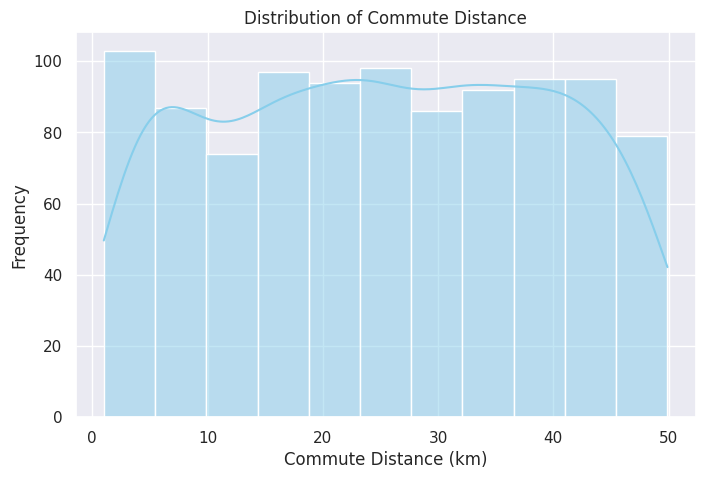

<ipython-input-7-cca17564c1f8>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='environmental_concern', data=Nudge, palette='Set2')


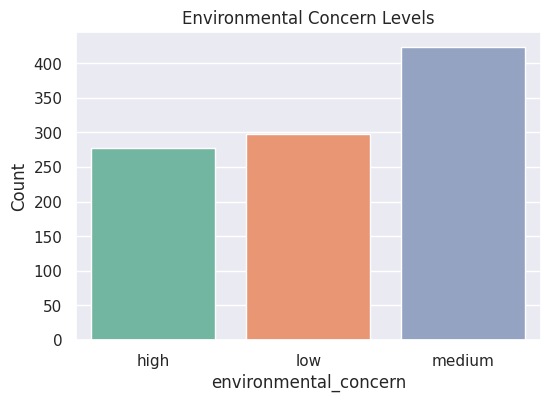

<ipython-input-7-cca17564c1f8>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='habit_strength', data=Nudge, palette='Blues')


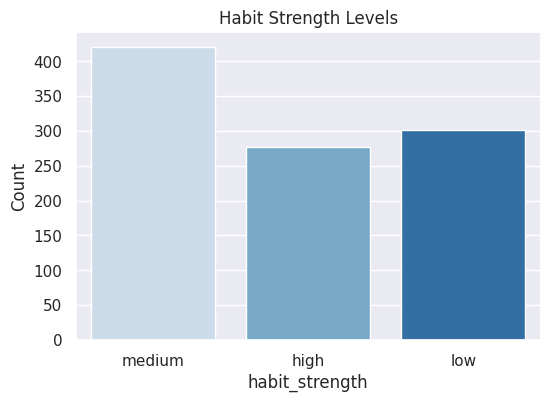

<ipython-input-7-cca17564c1f8>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nudge_type', y='switched_to_public_transport', data=Nudge, palette='muted')


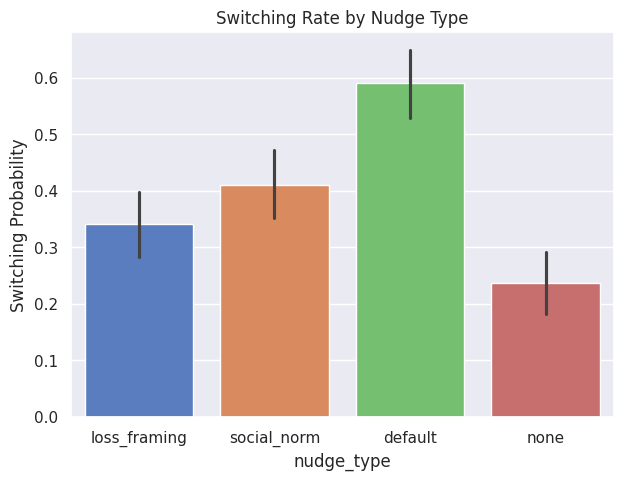

<ipython-input-7-cca17564c1f8>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='habit_strength', y='switched_to_public_transport', data=Nudge, palette='coolwarm')


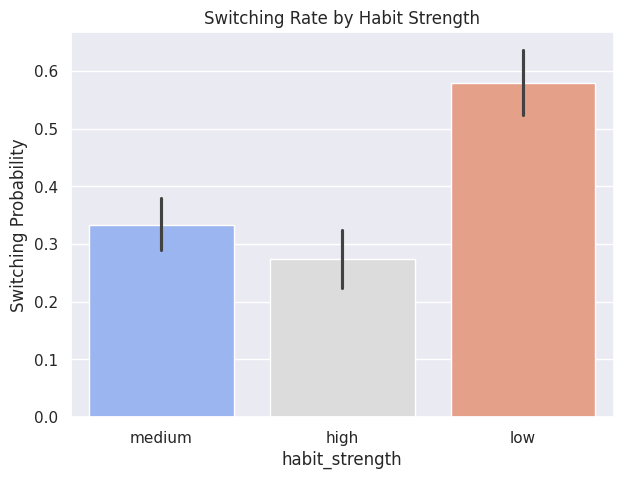

<ipython-input-7-cca17564c1f8>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tech_comfort', y='switched_to_public_transport', data=Nudge, palette='Set1')


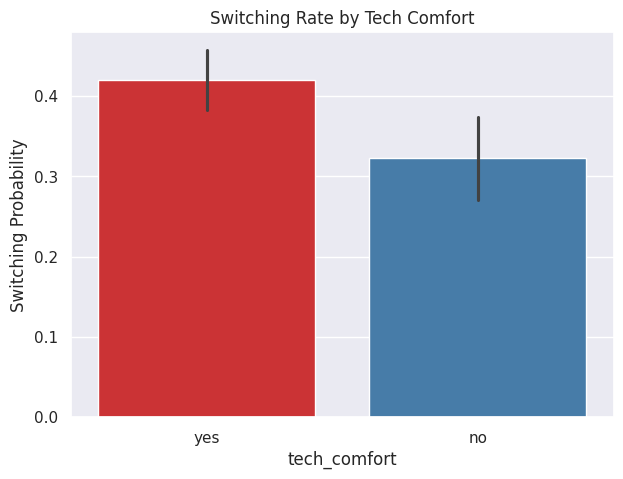

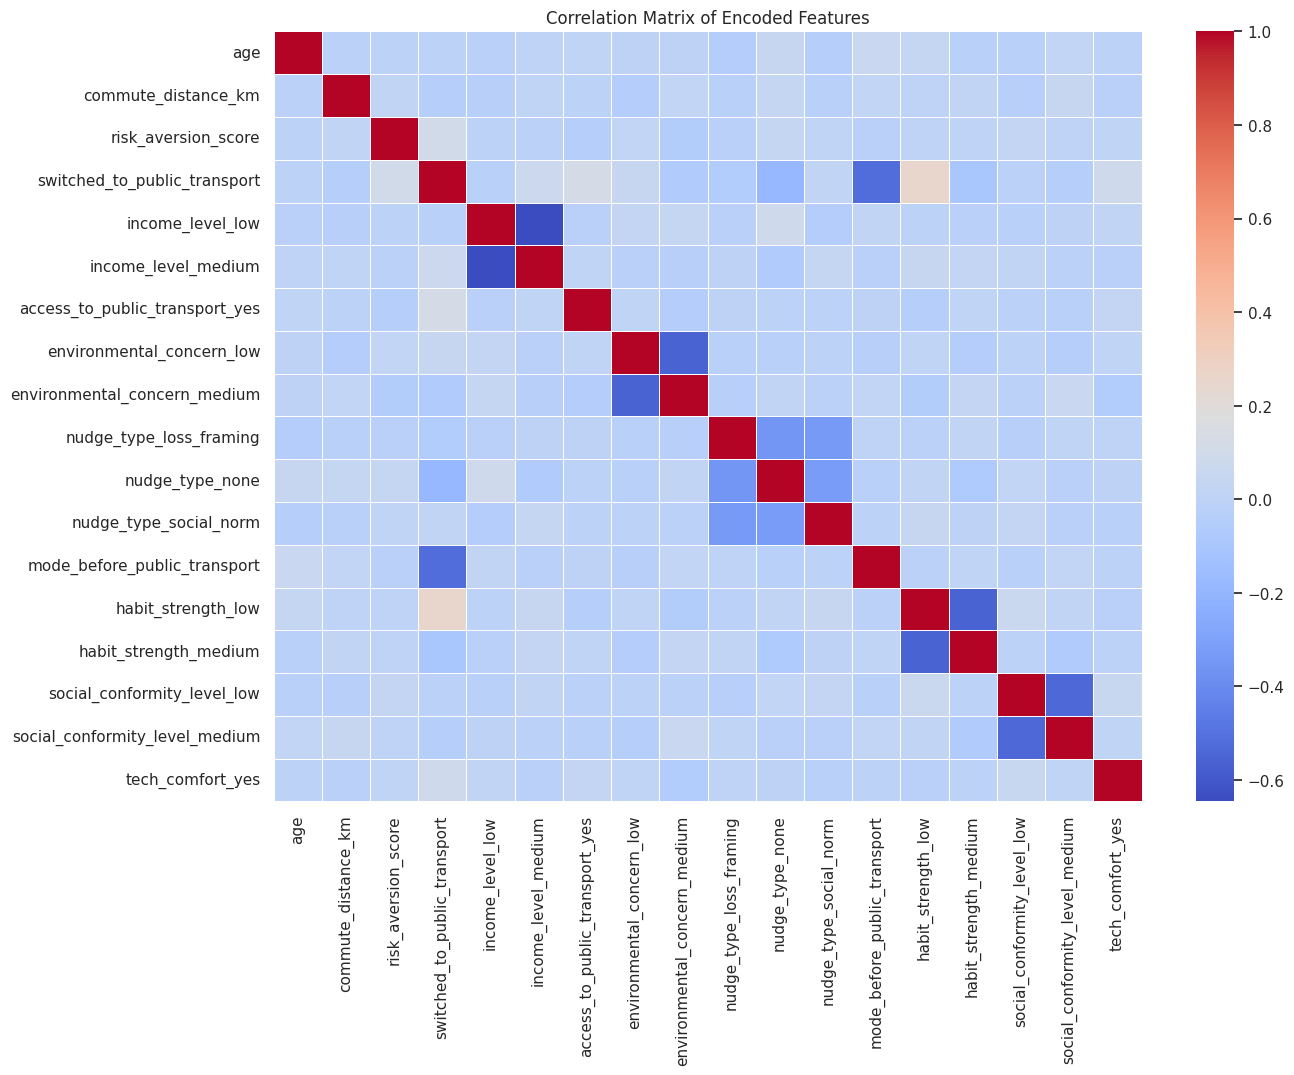

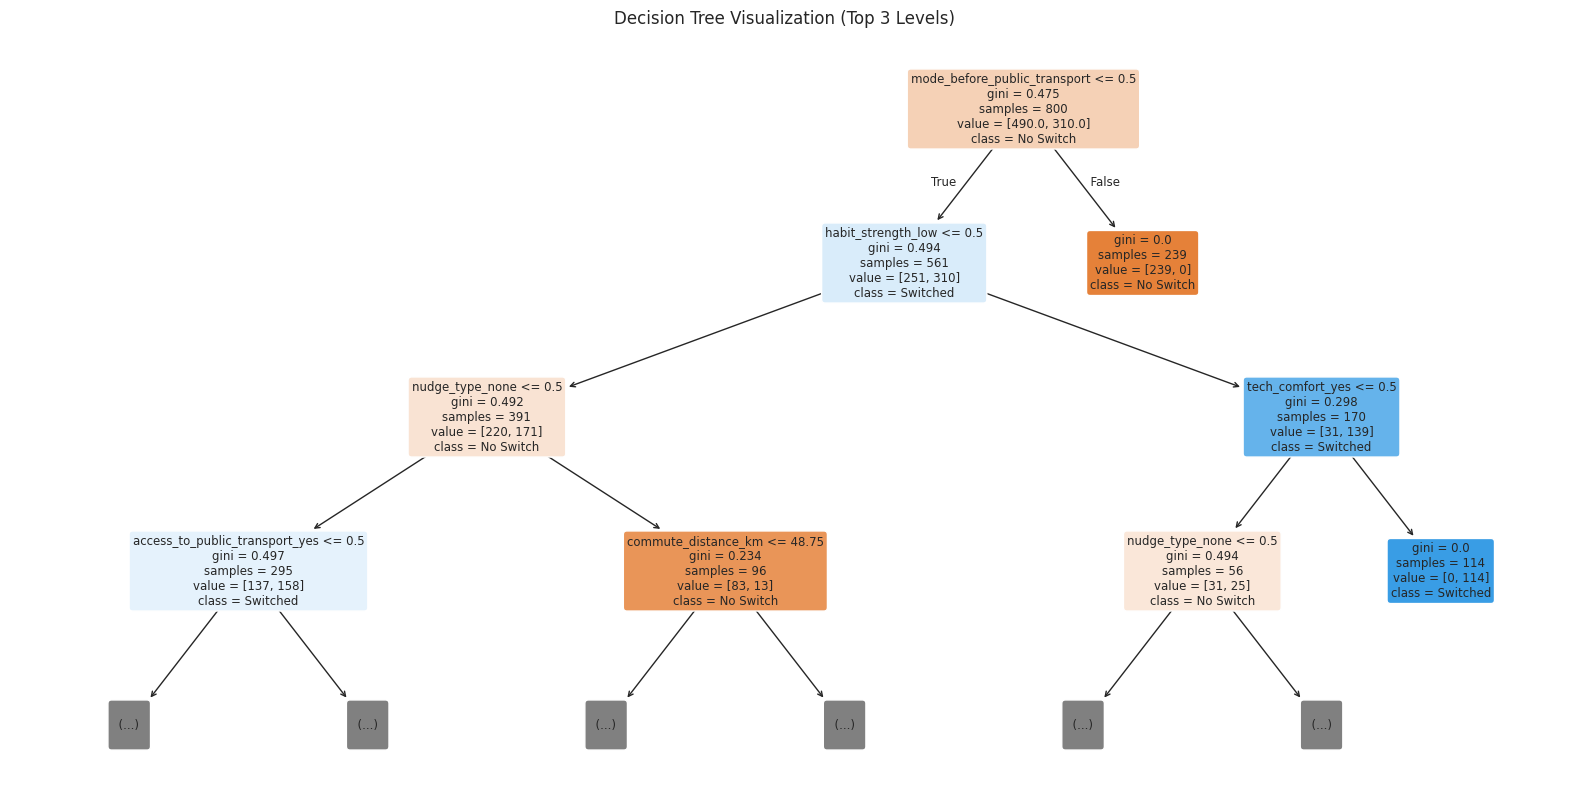

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Set plot style
sns.set(style="darkgrid")

# --- UNIVARIATE ANALYSIS ---

# 1. Distribution of commute distance
plt.figure(figsize=(8, 5))
sns.histplot(Nudge['commute_distance_km'], kde=True, color='skyblue')
plt.title("Distribution of Commute Distance")
plt.xlabel("Commute Distance (km)")
plt.ylabel("Frequency")
plt.show()

# 2. Count of environmental concern levels
plt.figure(figsize=(6, 4))
sns.countplot(x='environmental_concern', data=Nudge, palette='Set2')
plt.title("Environmental Concern Levels")
plt.ylabel("Count")
plt.show()

# 3. Count of habit strength levels (new feature)
plt.figure(figsize=(6, 4))
sns.countplot(x='habit_strength', data=Nudge, palette='Blues')
plt.title("Habit Strength Levels")
plt.ylabel("Count")
plt.show()

# --- BIVARIATE ANALYSIS ---

# 4. Switching rate by nudge type
plt.figure(figsize=(7, 5))
sns.barplot(x='nudge_type', y='switched_to_public_transport', data=Nudge, palette='muted')
plt.title("Switching Rate by Nudge Type")
plt.ylabel("Switching Probability")
plt.show()

# 5. Switching rate by habit strength
plt.figure(figsize=(7, 5))
sns.barplot(x='habit_strength', y='switched_to_public_transport', data=Nudge, palette='coolwarm')
plt.title("Switching Rate by Habit Strength")
plt.ylabel("Switching Probability")
plt.show()

# 6. Switching rate by tech comfort
plt.figure(figsize=(7, 5))
sns.barplot(x='tech_comfort', y='switched_to_public_transport', data=Nudge, palette='Set1')
plt.title("Switching Rate by Tech Comfort")
plt.ylabel("Switching Probability")
plt.show()

# --- CORRELATION MATRIX ---

# Only use numerical features (after encoding)
correlation_matrix = Nudge_encoded.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Correlation Matrix of Encoded Features")
plt.show()

# --- DECISION TREE VISUALIZATION (Make sure tree_model and X are defined) ---

plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=X.columns,
          class_names=['No Switch', 'Switched'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Decision Tree Visualization (Top 3 Levels)")
plt.show()